In [1]:
using LinearAlgebra
#using PlotlyJS
include("../src/fxio.jl")
include("../src/kabsch_umeyama.jl")


dihedaral (generic function with 1 method)

In [3]:
pdbpath = "../testpdb/3EFM.pdb"
seqxyz = pdb2seqxyz(pdbpath)
seqxyz4mers = coords2kmers(seqxyz, 4, "ca")

seq = join(seqxyz4mers[1][1:4,1])
xyz = seqxyz4mers[3][1:4,2:4]



4×3 Matrix{Any}:
 44.827  18.262  -0.076
 47.895  16.478   1.341
 48.826  19.138   3.903
 47.109  17.359   6.841

In [15]:
function dihedaral(xyzmatrix::Matrix{T}) where {T}

    if size(xyzmatrix) != (4, 3)

        error("Input matrix must be of size (4, 3)!")

    end

    p1 = xyzmatrix[1,1:3]
    p2 = xyzmatrix[2,1:3]
    p3 = xyzmatrix[3,1:3]
    p4 = xyzmatrix[4,1:3]

    b1 = p2 .- p1
    b2 = p3 .- p2
    b3 = p4 .- p3

    # Normalize the vectors
    norm_b1 = norm(b1)
    norm_b2 = norm(b2)
    norm_b3 = norm(b3)

    norm_vec1 = b1 ./ norm_b1
    norm_vec2 = b2 ./ norm_b2
    norm_vec3 = b3 ./ norm_b3

    # Compute normals
    n1 = cross(norm_vec1, norm_vec2)
    n2 = cross(norm_vec2, norm_vec3)

    # Compute the dihidral
    x = dot(n1, n2)
    y = dot(cross(n1, n2), norm_vec2)

    dihidral = atan(y, x) * (180 / π)  # Converted to degrees * (180 / π)

    # Compute angles
    angle1 = acos(dot(b1, b2) / (norm_b1 * norm_b2)) * (180 / π)
    angle2 = acos(dot(b2, b3) / (norm_b2 * norm_b3)) * (180 / π)



    return dihidral, angle1, angle2

end

dihedaral(xyz)

(97.62070410864986, 83.12901661455292, 85.30732103522091)

In [16]:
 for (i,seqxyz4mer) in enumerate(seqxyz4mers)
    
    println(i, " < ", dihedaral(seqxyz4mer[:,2:4]))
 end

1 < (91.47338359147663, 53.288063564739794, 59.95898638368619)
2 < (168.46082387794834, 68.6451906681907, 78.67240014338965)
3 < (97.62070410864986, 83.12901661455292, 85.30732103522091)
4 < (-151.07978194982843, 44.471190931223774, 89.55139567979172)
5 < (-135.4915007542968, 39.99246513771716, 84.3546530799767)
6 < (-170.57188508623753, 47.64254338550907, 73.88656855423176)
7 < (0.5114527292610471, 80.2049170082221, 71.75793326920811)
8 < (-114.4981630194539, 60.46018566498172, 74.99756029443687)
9 < (-105.17637548173384, 64.10879758752166, 89.44039827558986)
10 < (90.60443326488928, 85.33460764095511, 68.58746190932574)
11 < (-83.1752160140989, 42.13842861266512, 74.94875859281711)
12 < (-149.55248334952188, 39.19205234435629, 47.915832914579624)
13 < (-105.11847596813965, 49.135660304114296, 92.6187106926394)
14 < (52.50018075341131, 89.95367333133797, 88.56034889160122)
15 < (38.17739700729963, 88.14107089921082, 81.80266900981732)
16 < (-178.16723302821012, 73.0973811767718, 73.92

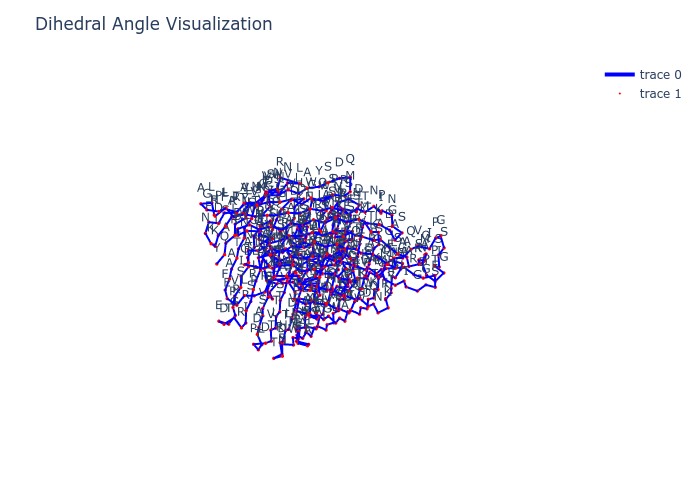

In [17]:
function catrace(seqxyz)

    trace_points = scatter3d(
            x=seqxyz[:,2], y=seqxyz[:,3], z=seqxyz[:,4],
            mode="markers+text",
            marker=attr(size=2, color="red"),
            text=seqxyz[:,1],
            textposition="top center"
        )

    trace_lines = scatter3d(
            x=seqxyz[:,2], y=seqxyz[:,3], z=seqxyz[:,4],
            mode="lines",
            line=attr(width=4, color="blue")
        )
        
    layout = Layout(
            title="Dihedral Angle Visualization",
            width=800,    # Set plot width
            height=600,   # Set plot height
            scene=attr(
                xaxis=attr(visible=false),
                yaxis=attr(visible=false),
                zaxis=attr(visible=false),
                camera=attr(
                    projection=attr(type="orthographic")  # Set perspective view
                )
            )
        )

    return plot([trace_lines, trace_points], layout)
end

catrace(seqxyz)